In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="FpdHSnr4zKdtmC49Nhbp")
project = rf.workspace("workspace-5ujvu").project("basketball-players-fy4c2-vfsuv")
version = project.version(17)
dataset = version.download("yolov5")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 53.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Basketball-Players-17 in yolov5pytorch:: 100%|██████████| 652/652 [00:00<00:00, 4513.55it/s]


In [ ]:
import shutil
shutil.move("Basketball-Players-17/train",
            "Basketball-Players-17/Basketball-Players-17/train/images")
shutil.move("Basketball-Players-17/valid",
            "Basketball-Players-17/Basketball-Players-17/valid")
shutil.move("Basketball-Players-17/test",
            "Basketball-Players-17/Basketball-Players-17/test/images")

'Basketball-Players-17/Basketball-Players-17/test/images'

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!yolo task=detect mode=train model=yolov5l6u.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True batch=8

Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Basketball-Players-17/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5l6u.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving player.pt to player.pt


In [ ]:
trained_model = list(uploaded.keys())[0]
model = YOLO(trained_model)

In [ ]:
import yaml

with open("Basketball-Players-17/data.yaml", "r") as f:
    data = yaml.safe_load(f)

data['test'] = "/content/Basketball-Players-17/Basketball-Players-17/test/images/images"

with open("Basketball-Players-17/data.yaml", "w") as f:
    yaml.dump(data, f)

metrics = model.val(data="Basketball-Players-17/data.yaml", split="test")

print("mAP50:     ", metrics.box.map50)
print("mAP50-95:  ", metrics.box.map)
print("Precision: ", metrics.box.mp)
print("Recall:    ", metrics.box.mr)

from IPython.display import Image, display
import glob

for img_path in sorted(glob.glob("runs/detect/val/*.png")):
    print(img_path)
    display(Image(filename=img_path))

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1016.7±344.7 MB/s, size: 64.2 KB)
val: Scanning /content/Basketball-Players-17/Basketball-Players-17/test/images/labels... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 372.6it/s 0.1s
val: New cache created: /content/Basketball-Players-17/Basketball-Players-17/test/images/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5s/it 3.1s
                   all         32        471      0.956       0.92      0.947      0.771
                  Ball         24         24          1      0.642      0.762      0.508
                 Clock         22         37      0.998          1      0.995      0.848
                  Hoop         25         25      0.988          1      0.995      0.814
               Overlay         28         36      0.797          1      0.987      0.

runs/detect/val4/BoxF1_curve.png


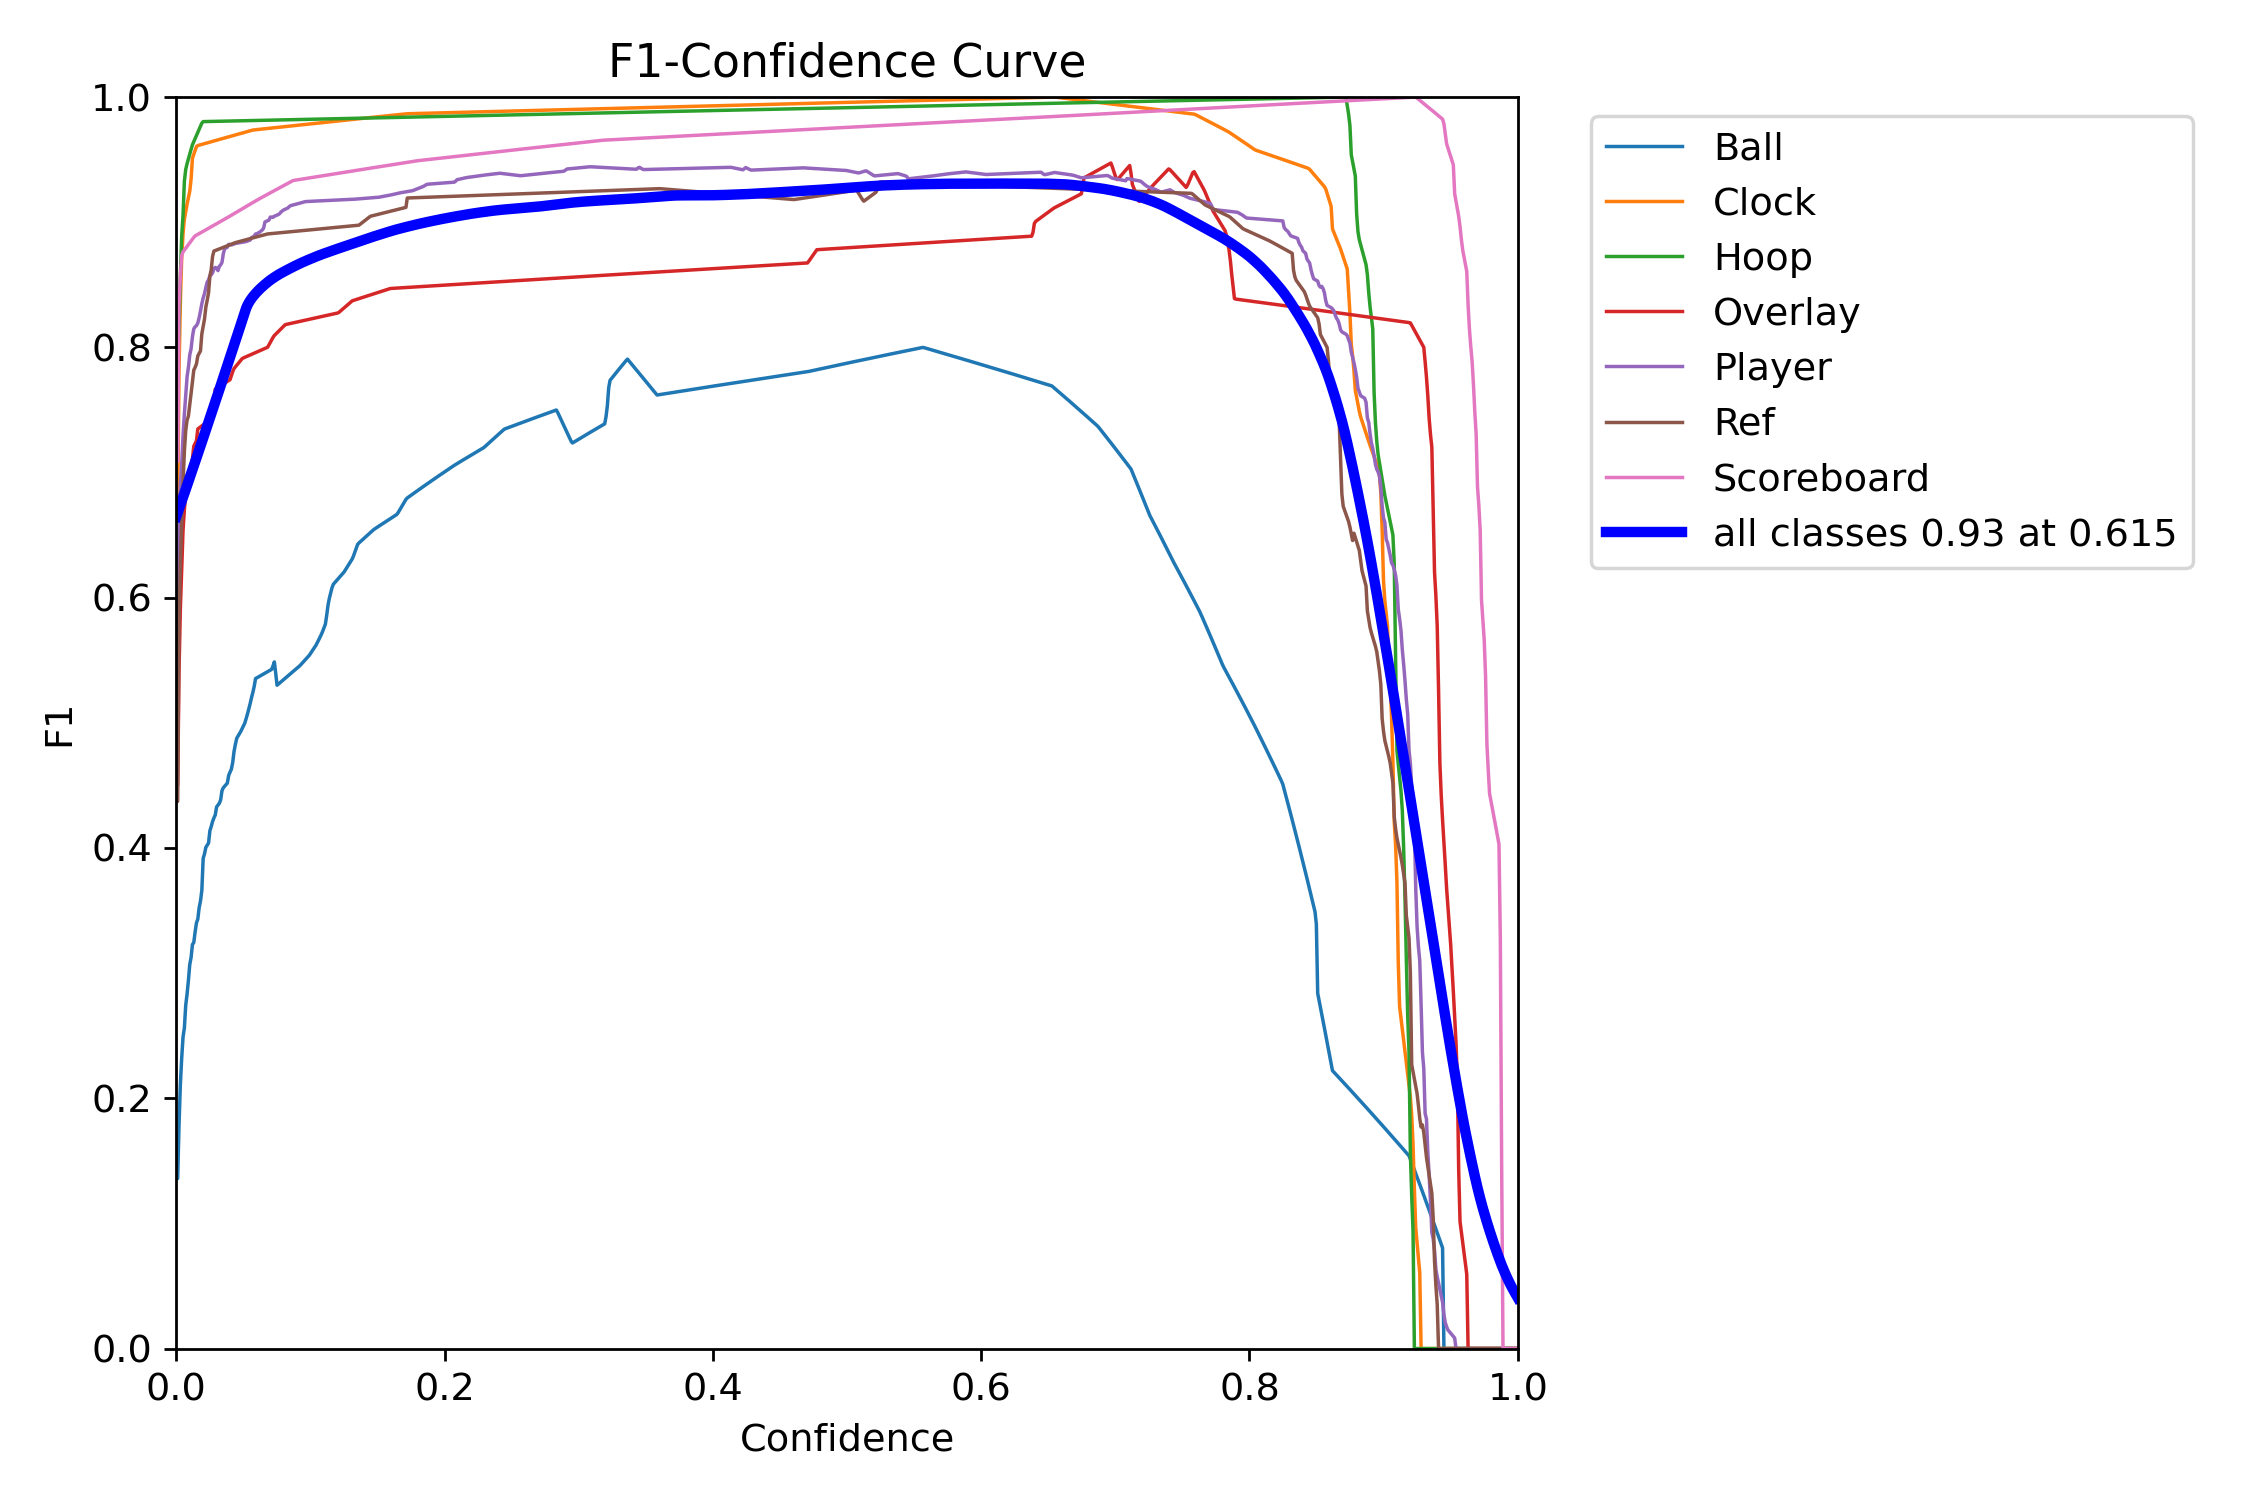

runs/detect/val4/BoxPR_curve.png


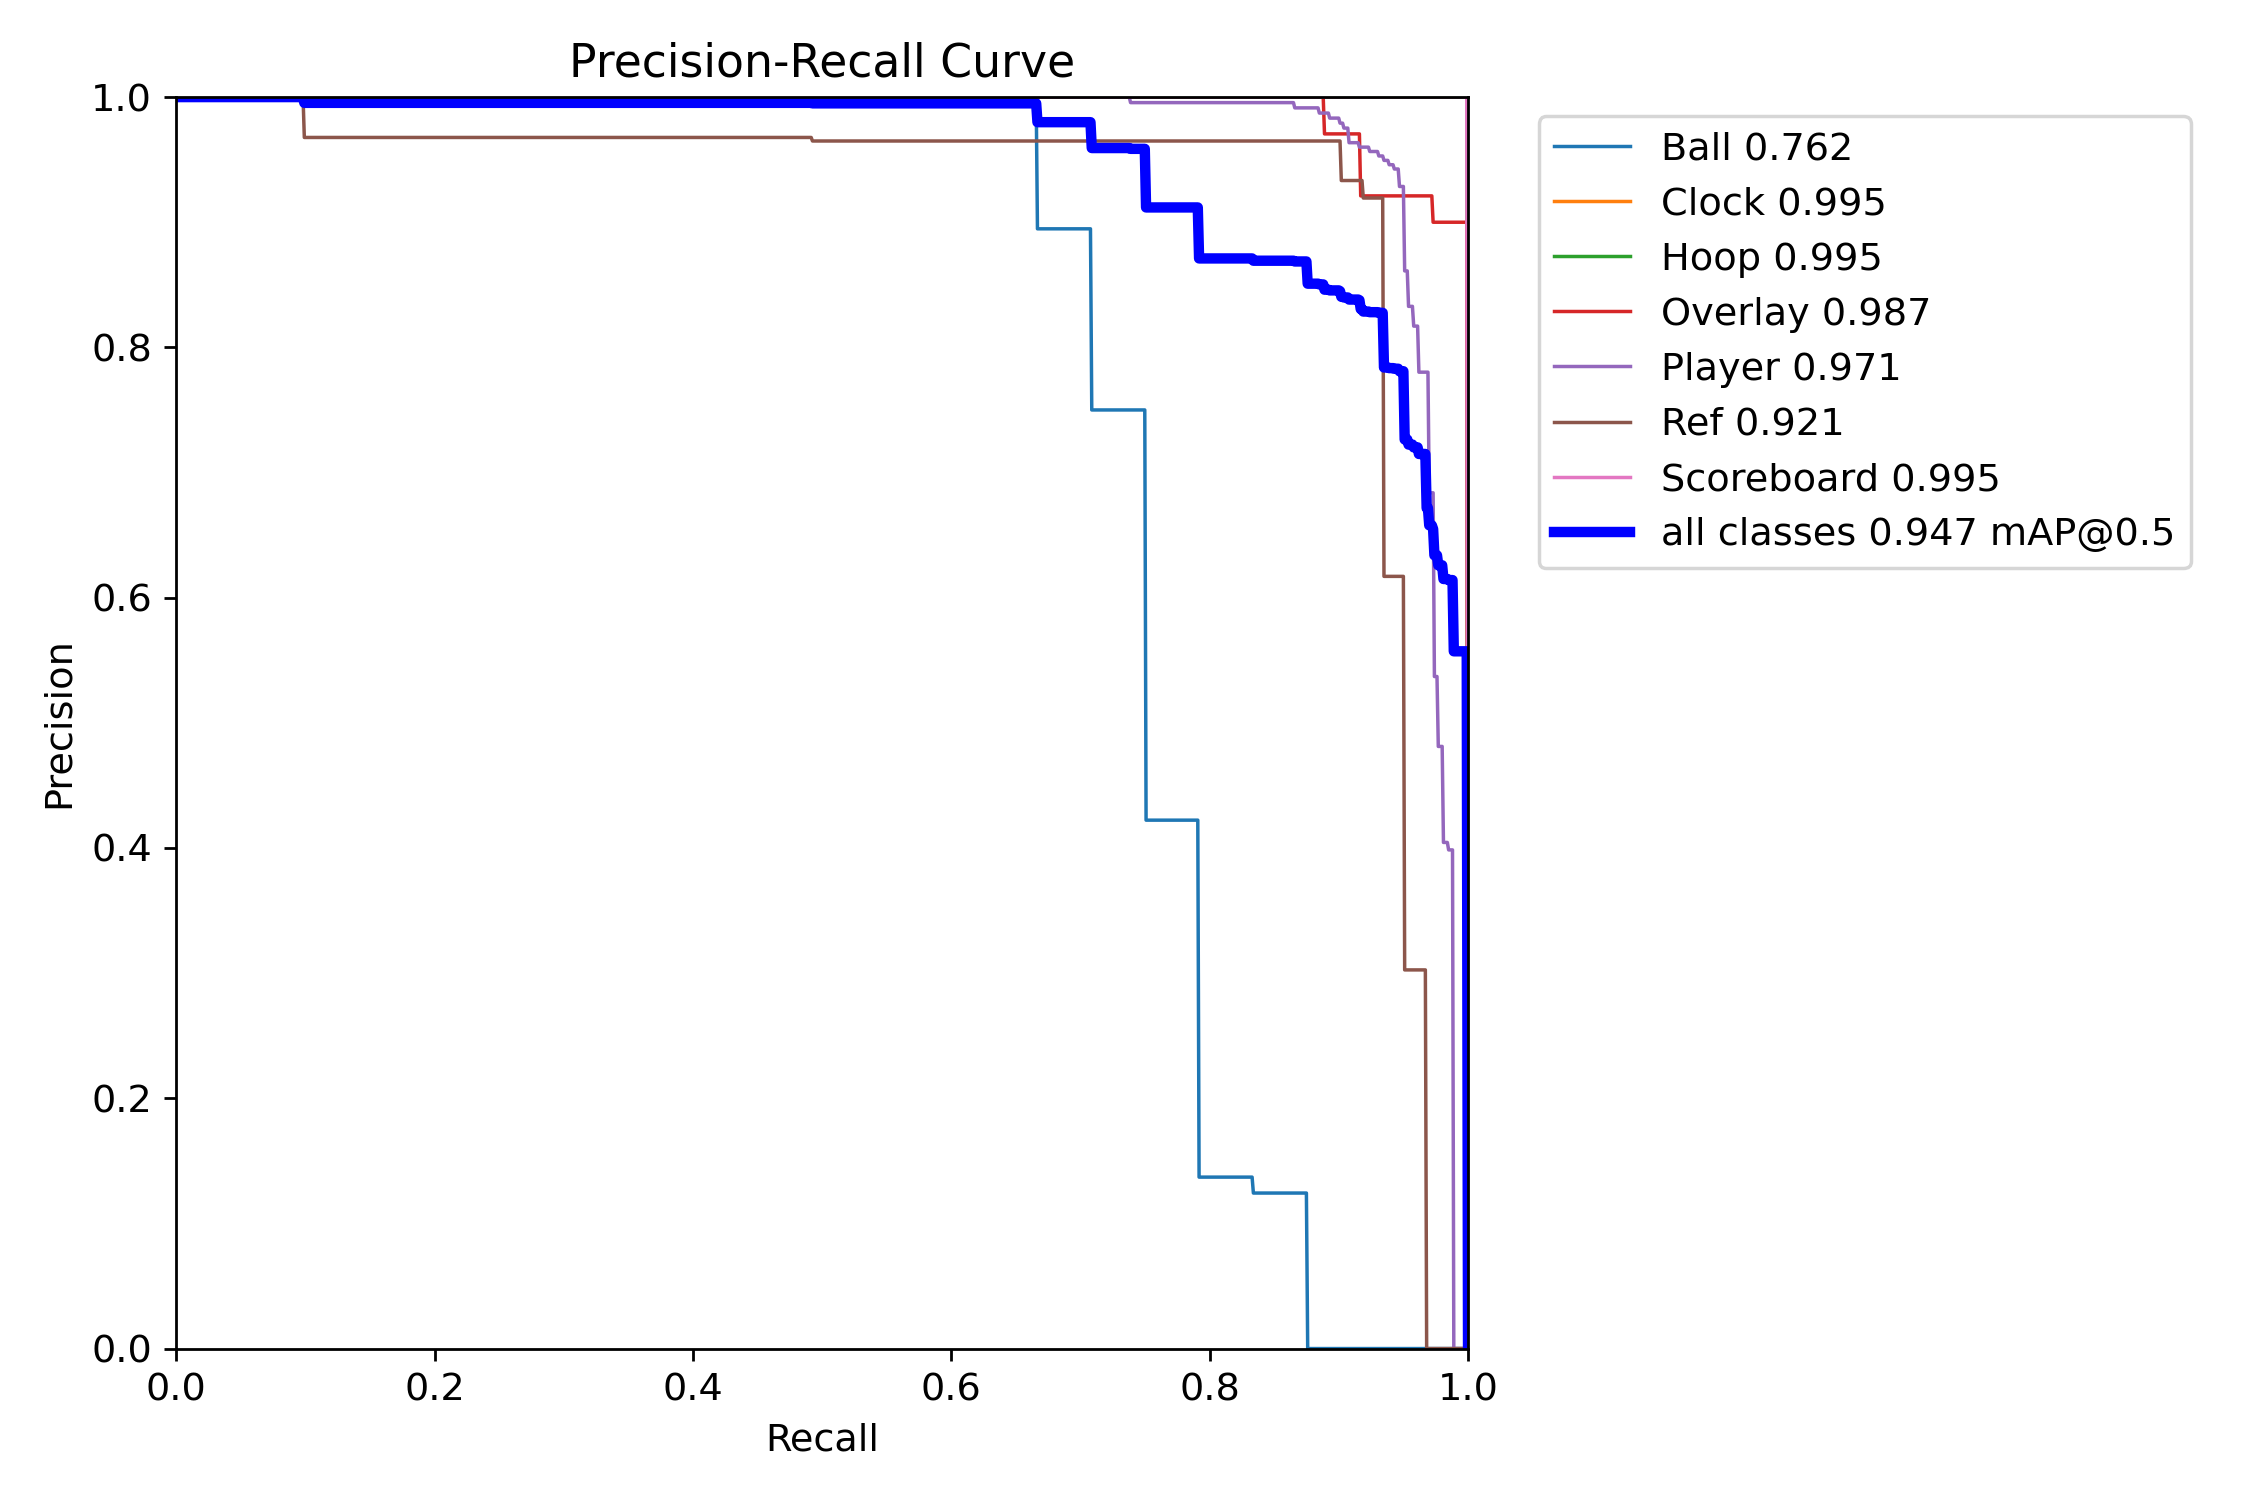

runs/detect/val4/BoxP_curve.png


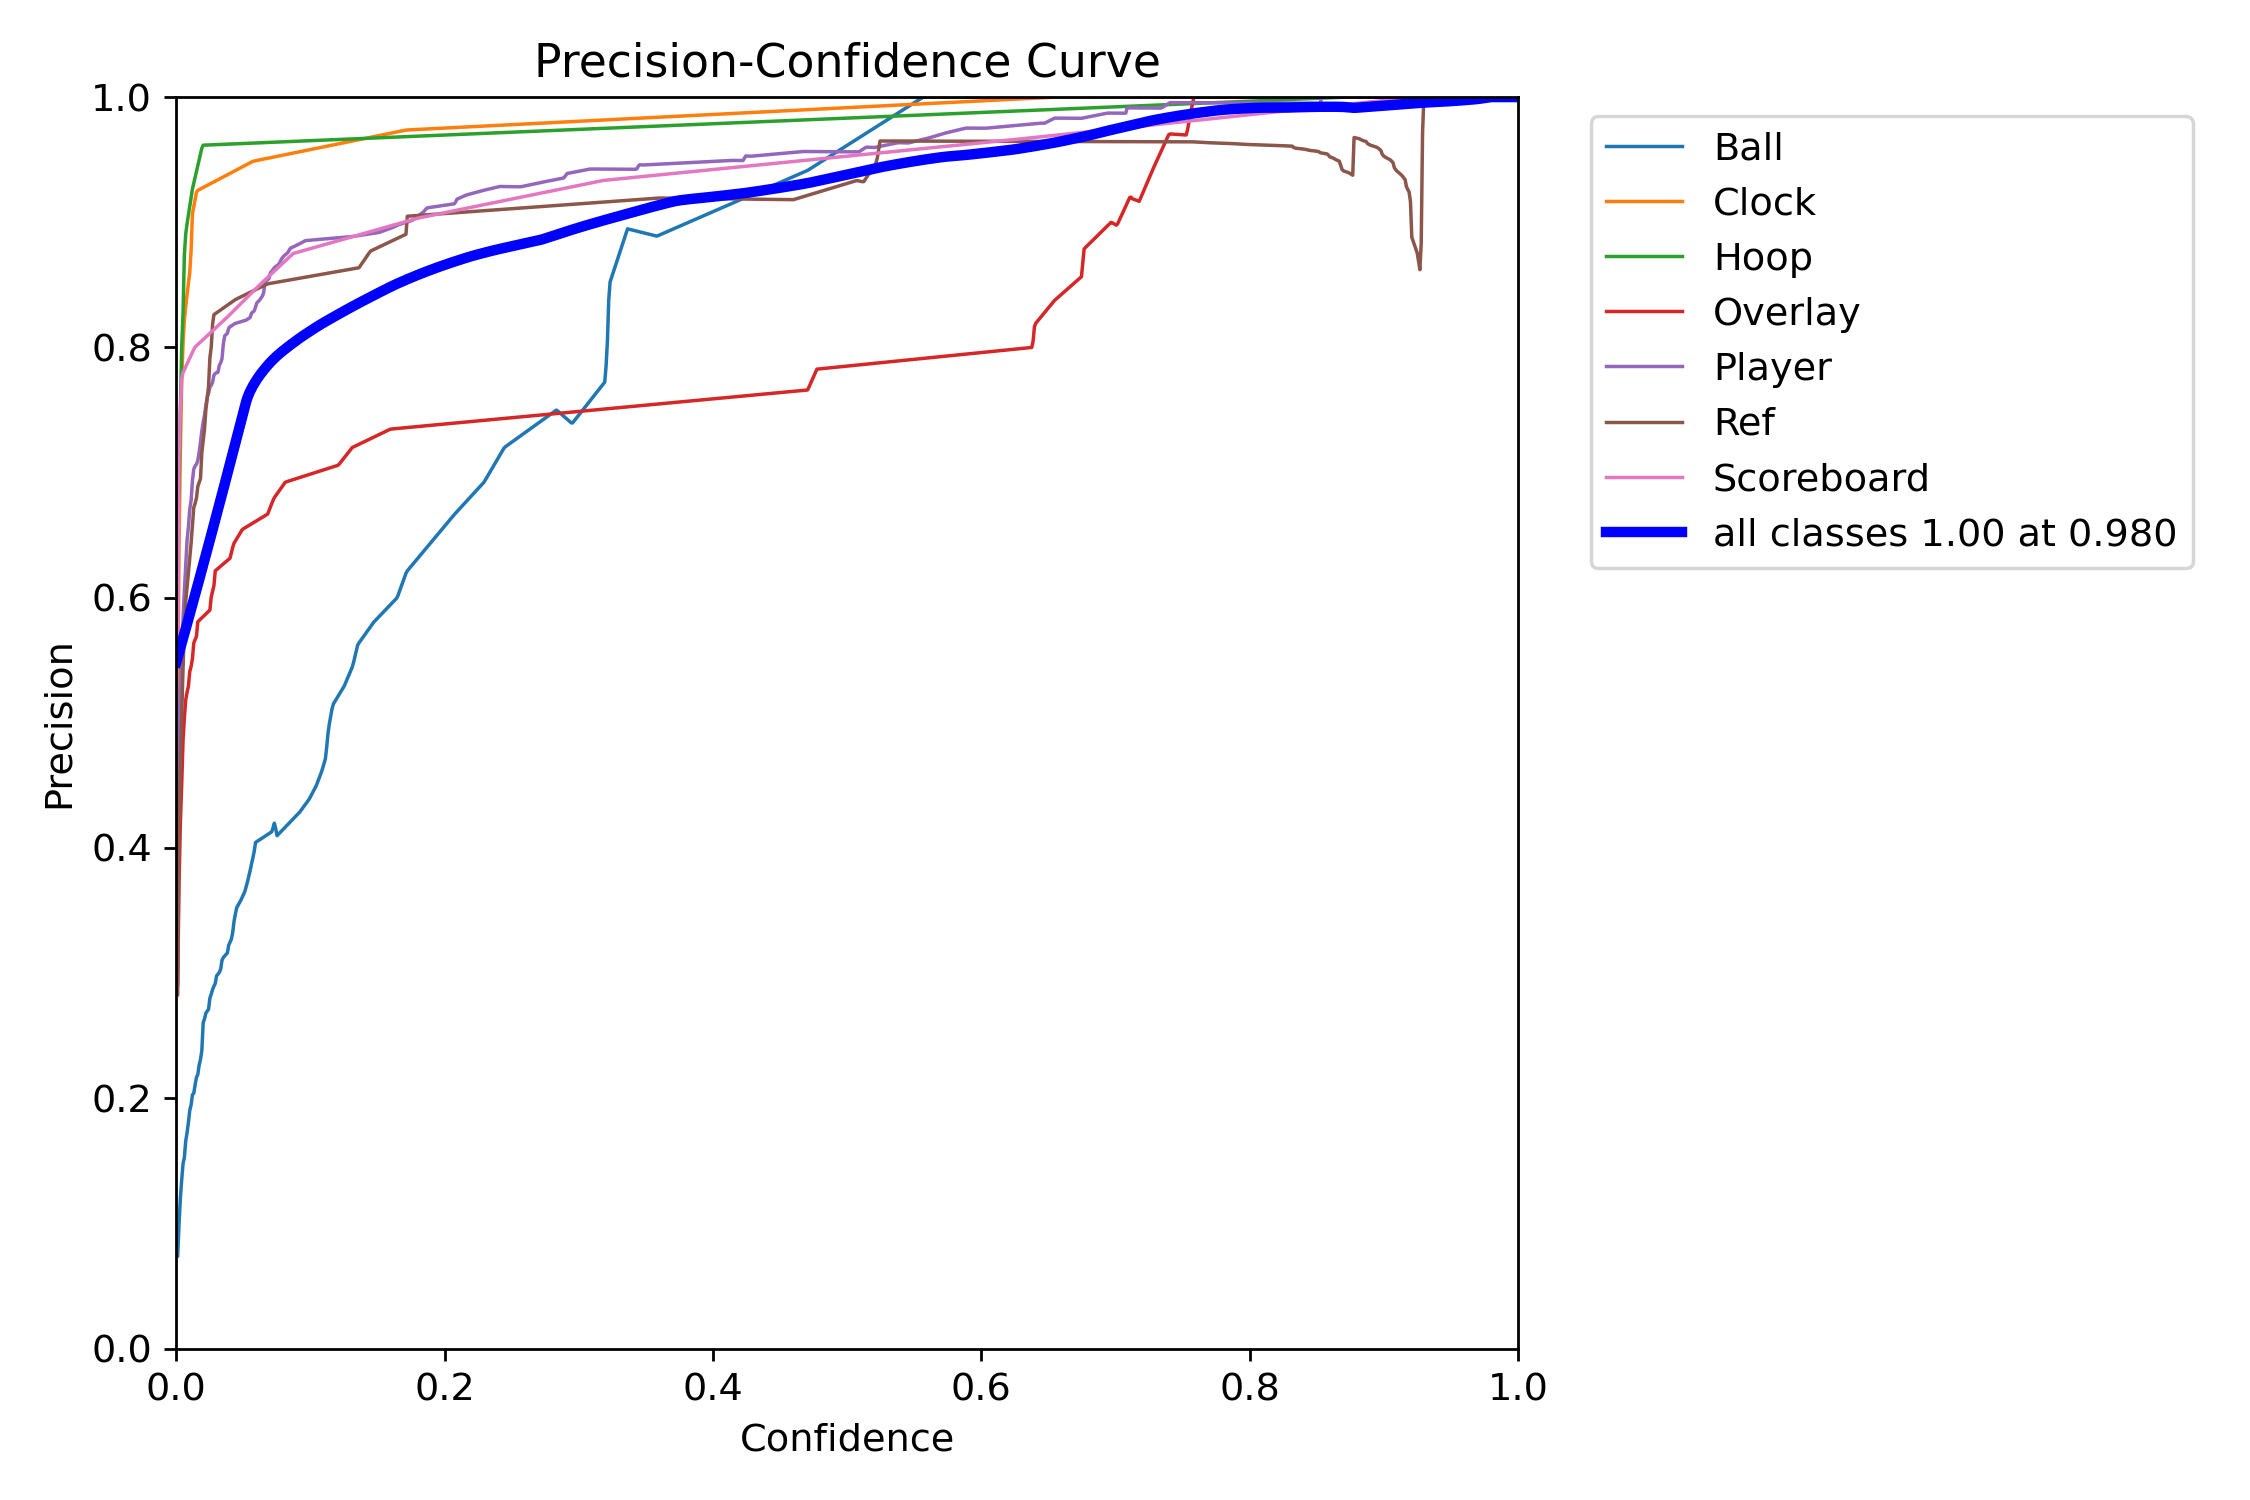

runs/detect/val4/BoxR_curve.png


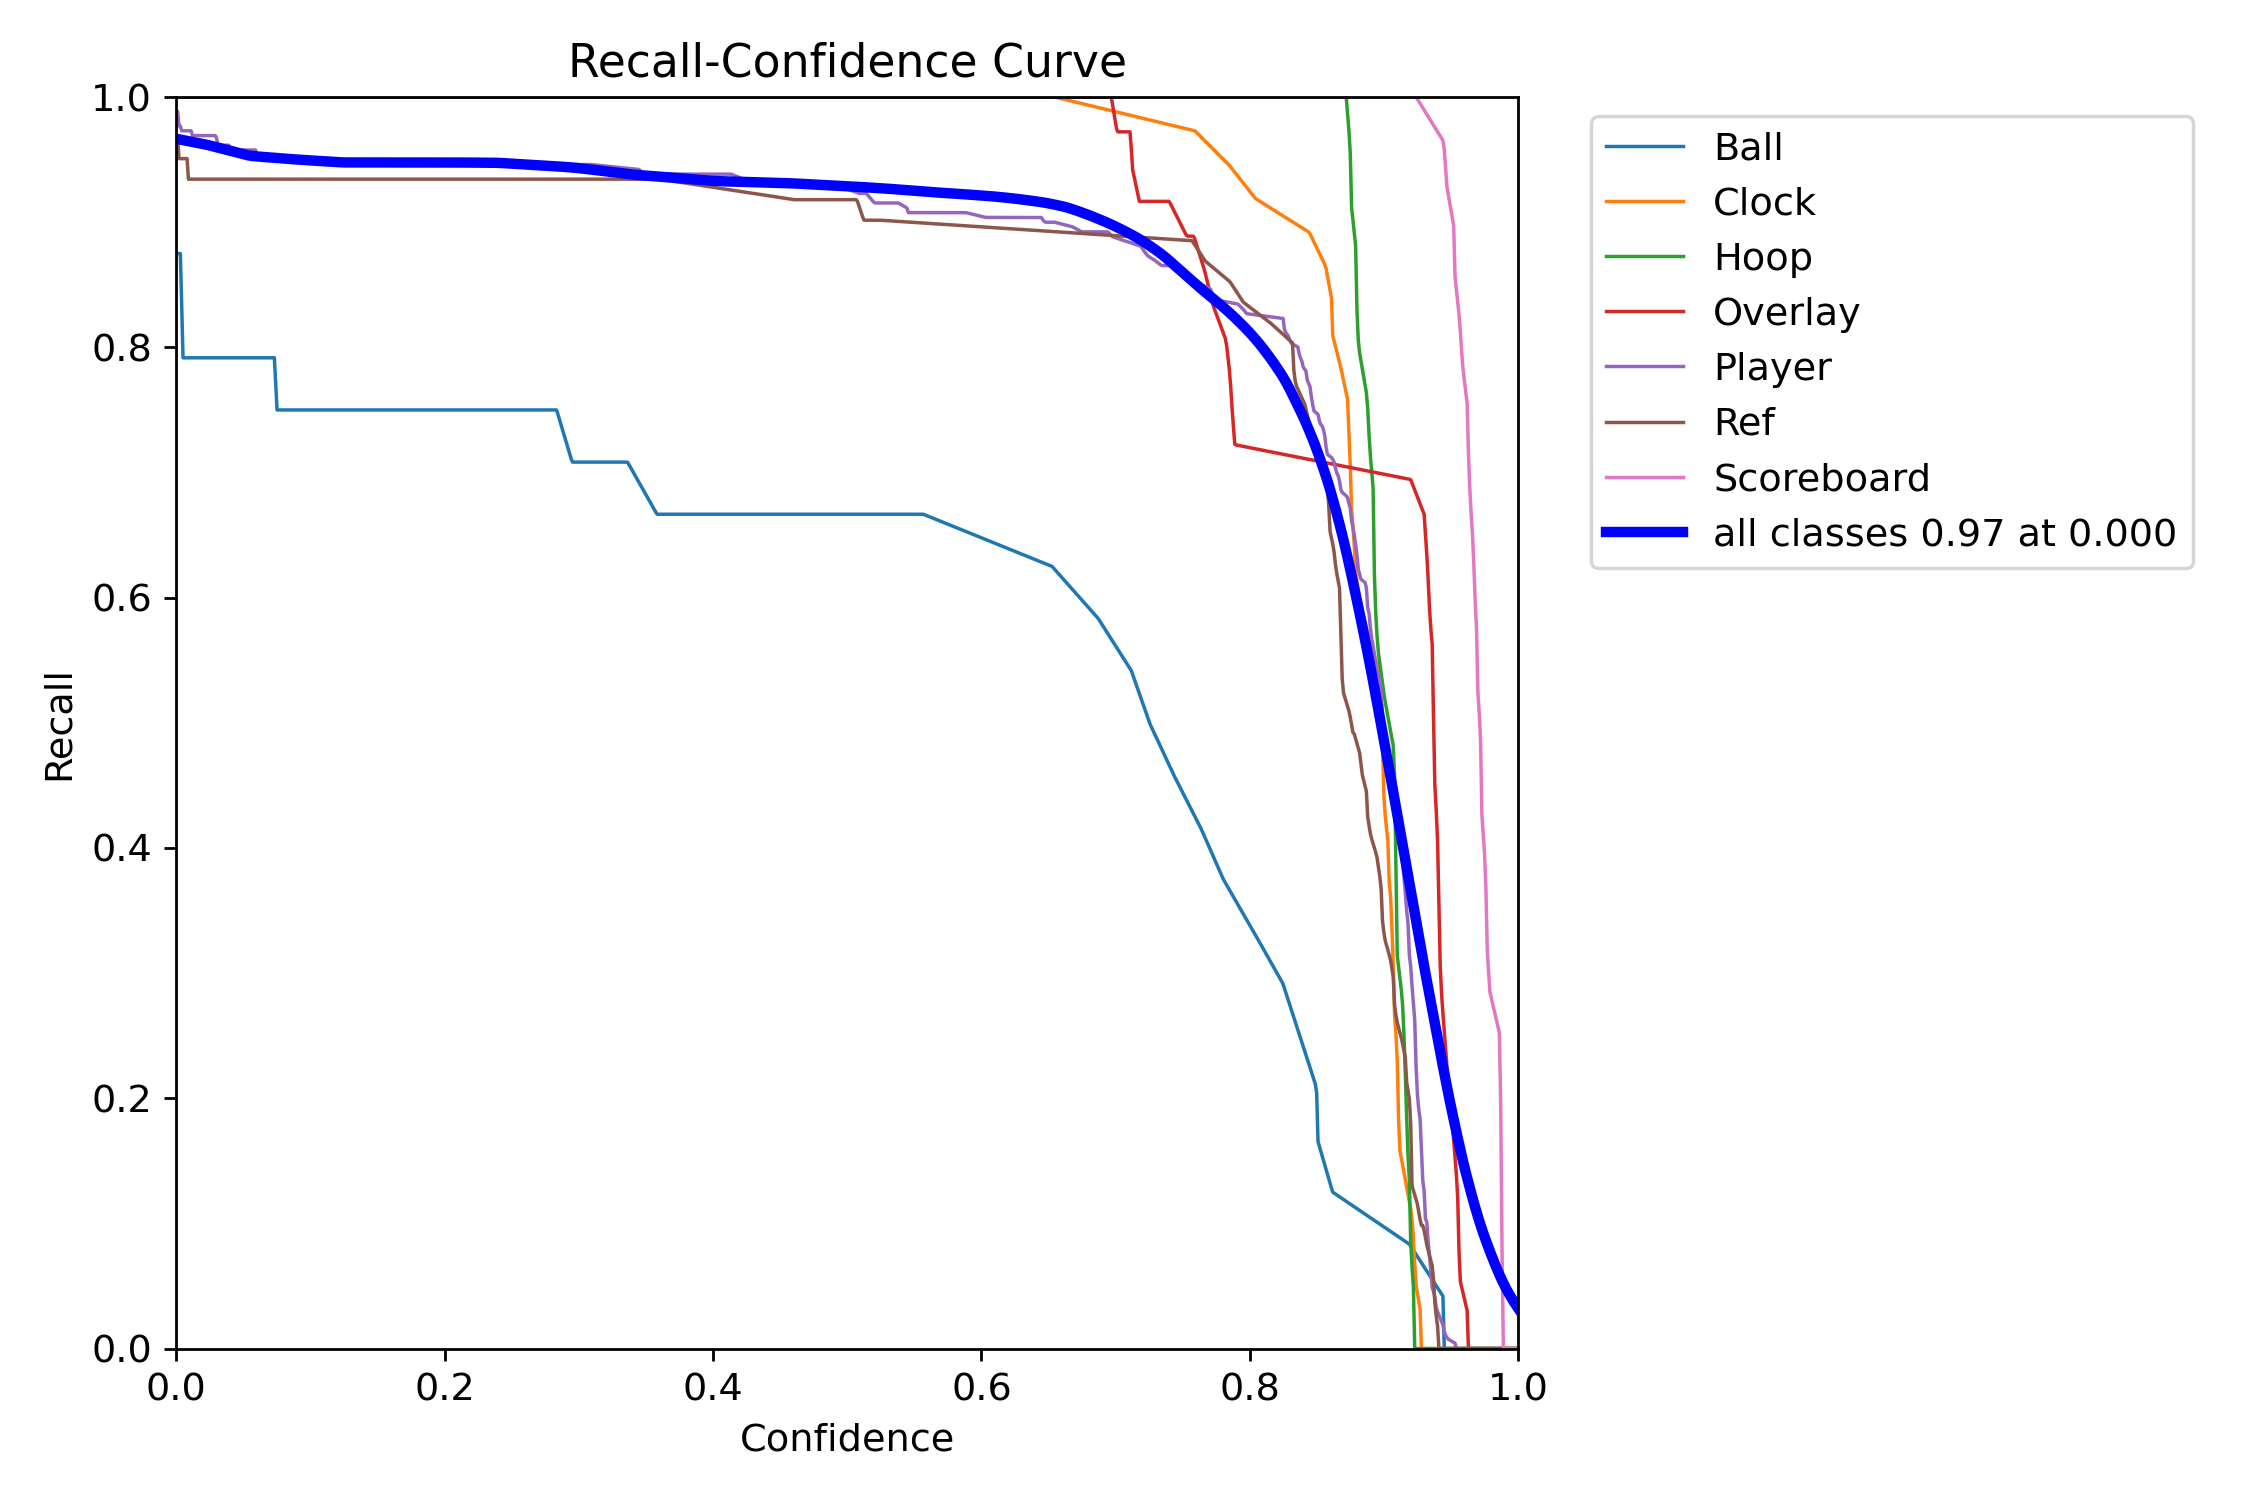

runs/detect/val4/confusion_matrix.png


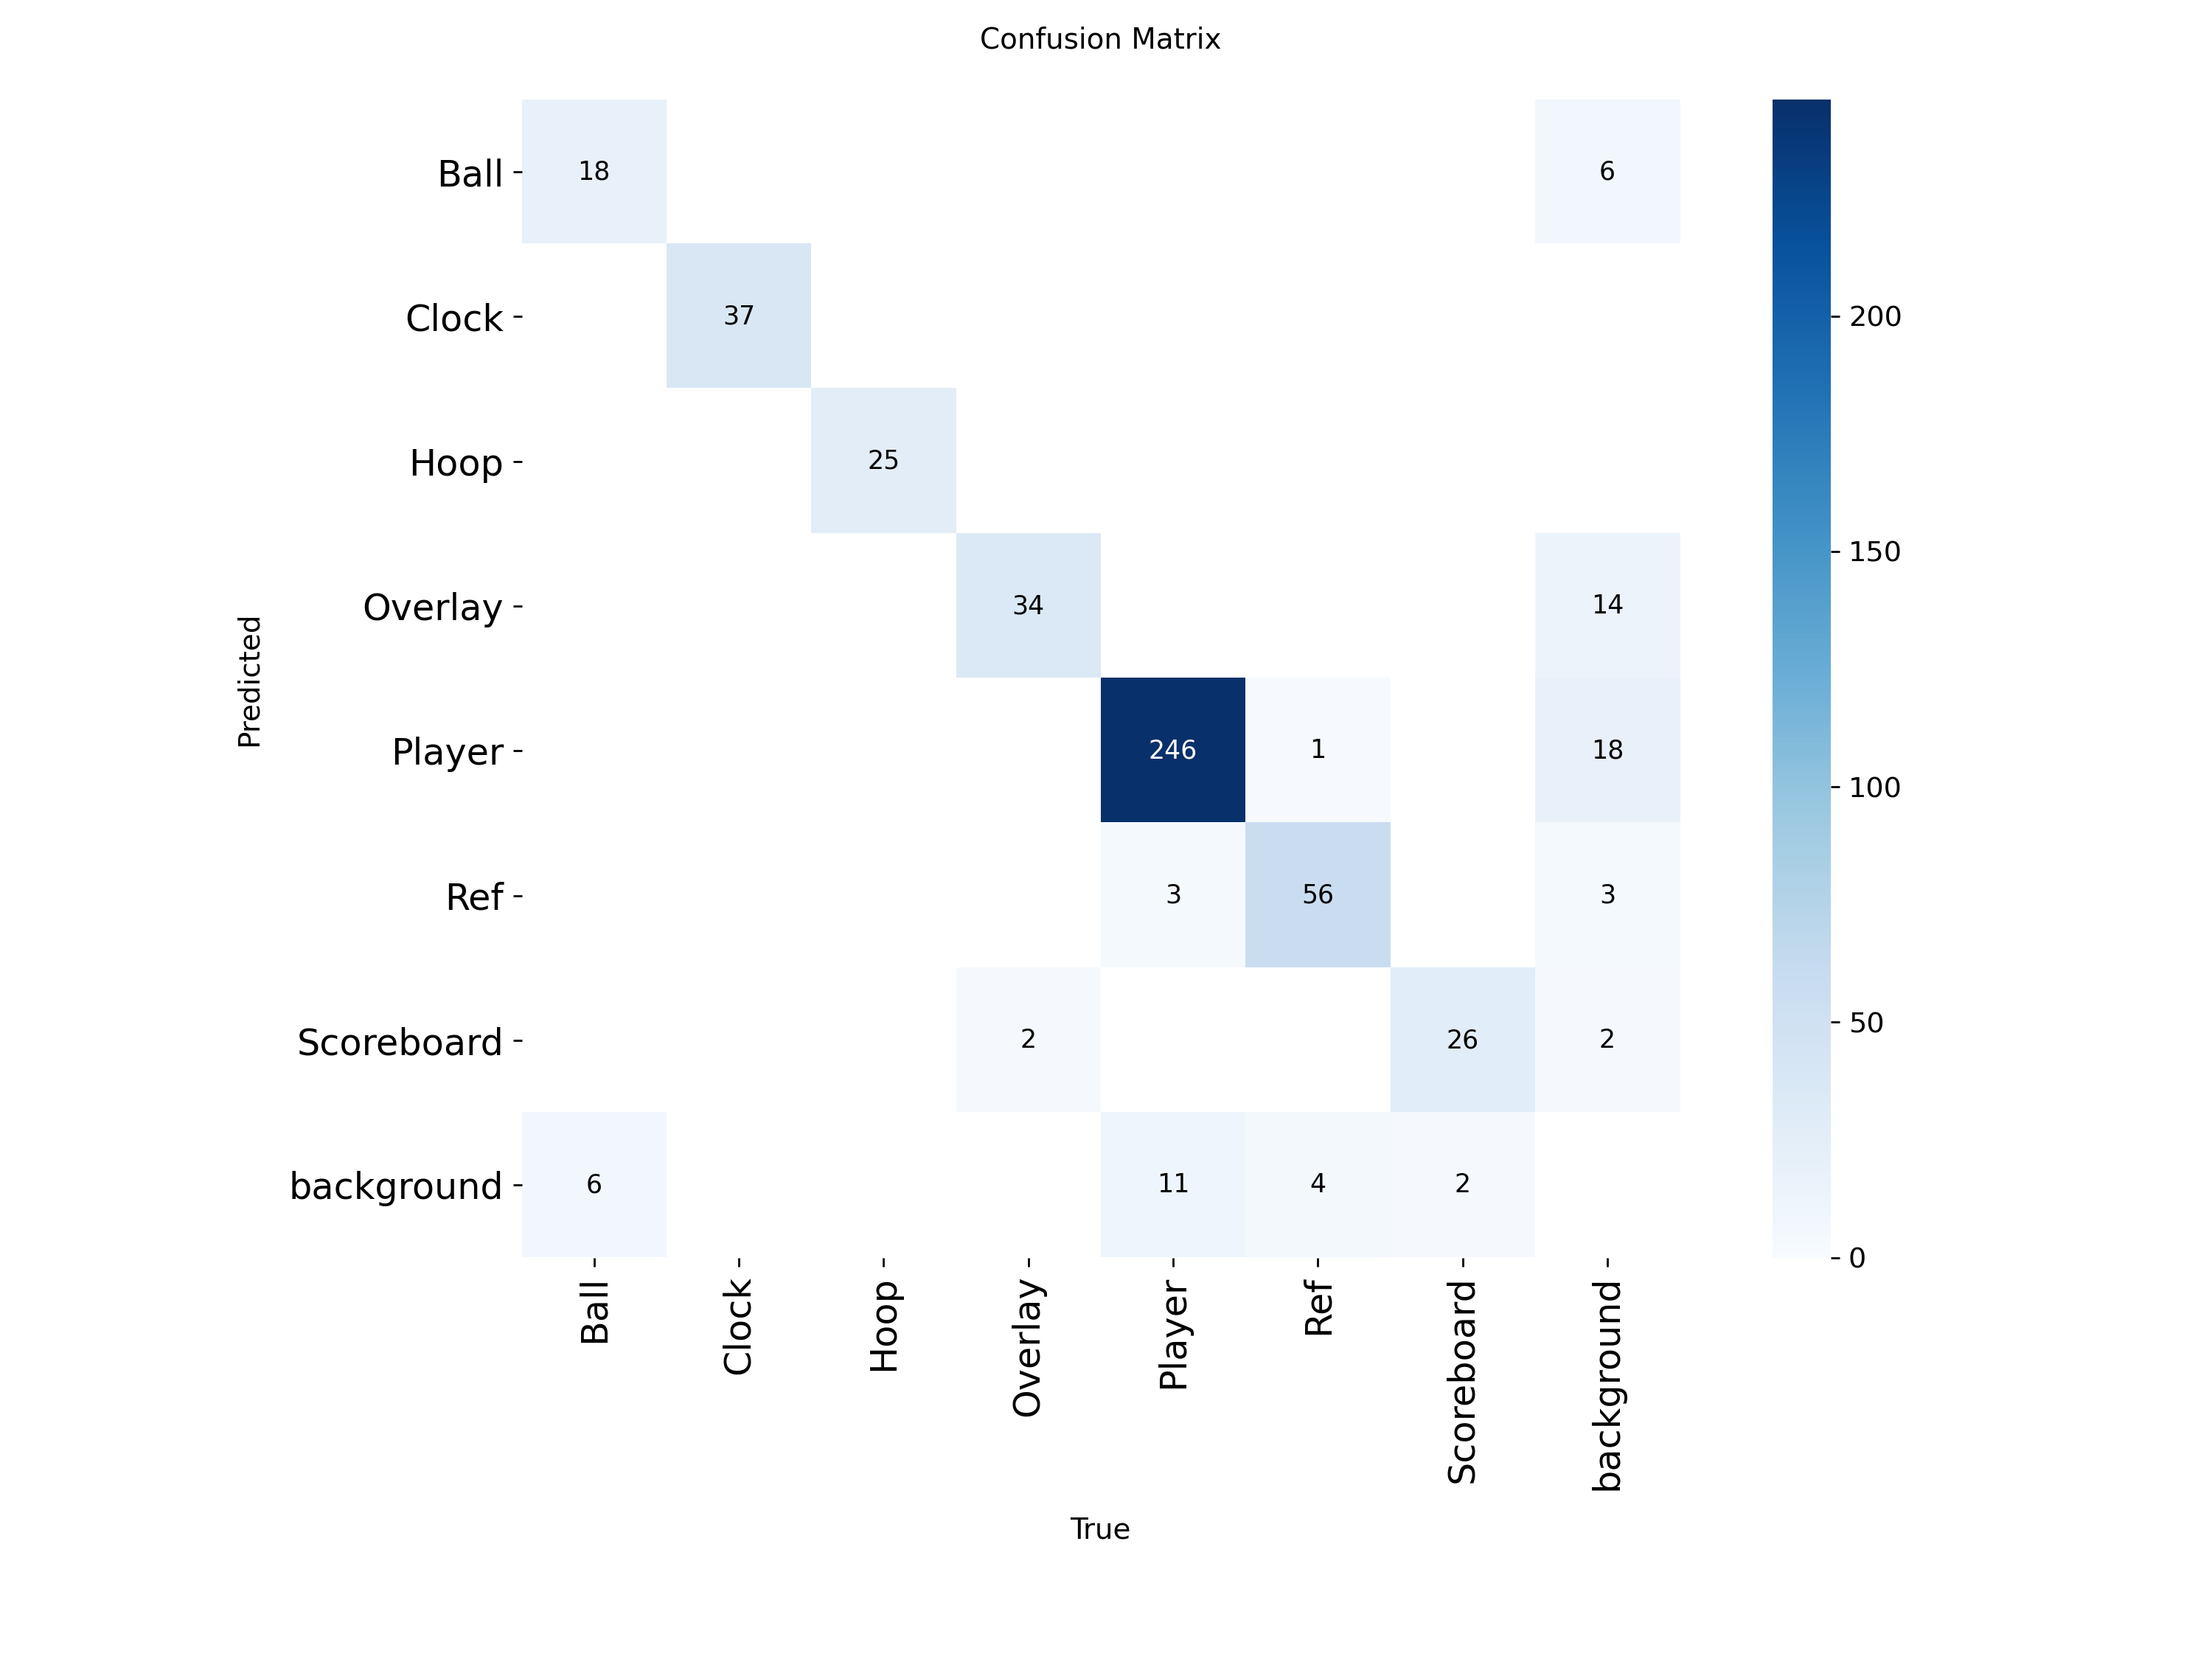

runs/detect/val4/confusion_matrix_normalized.png


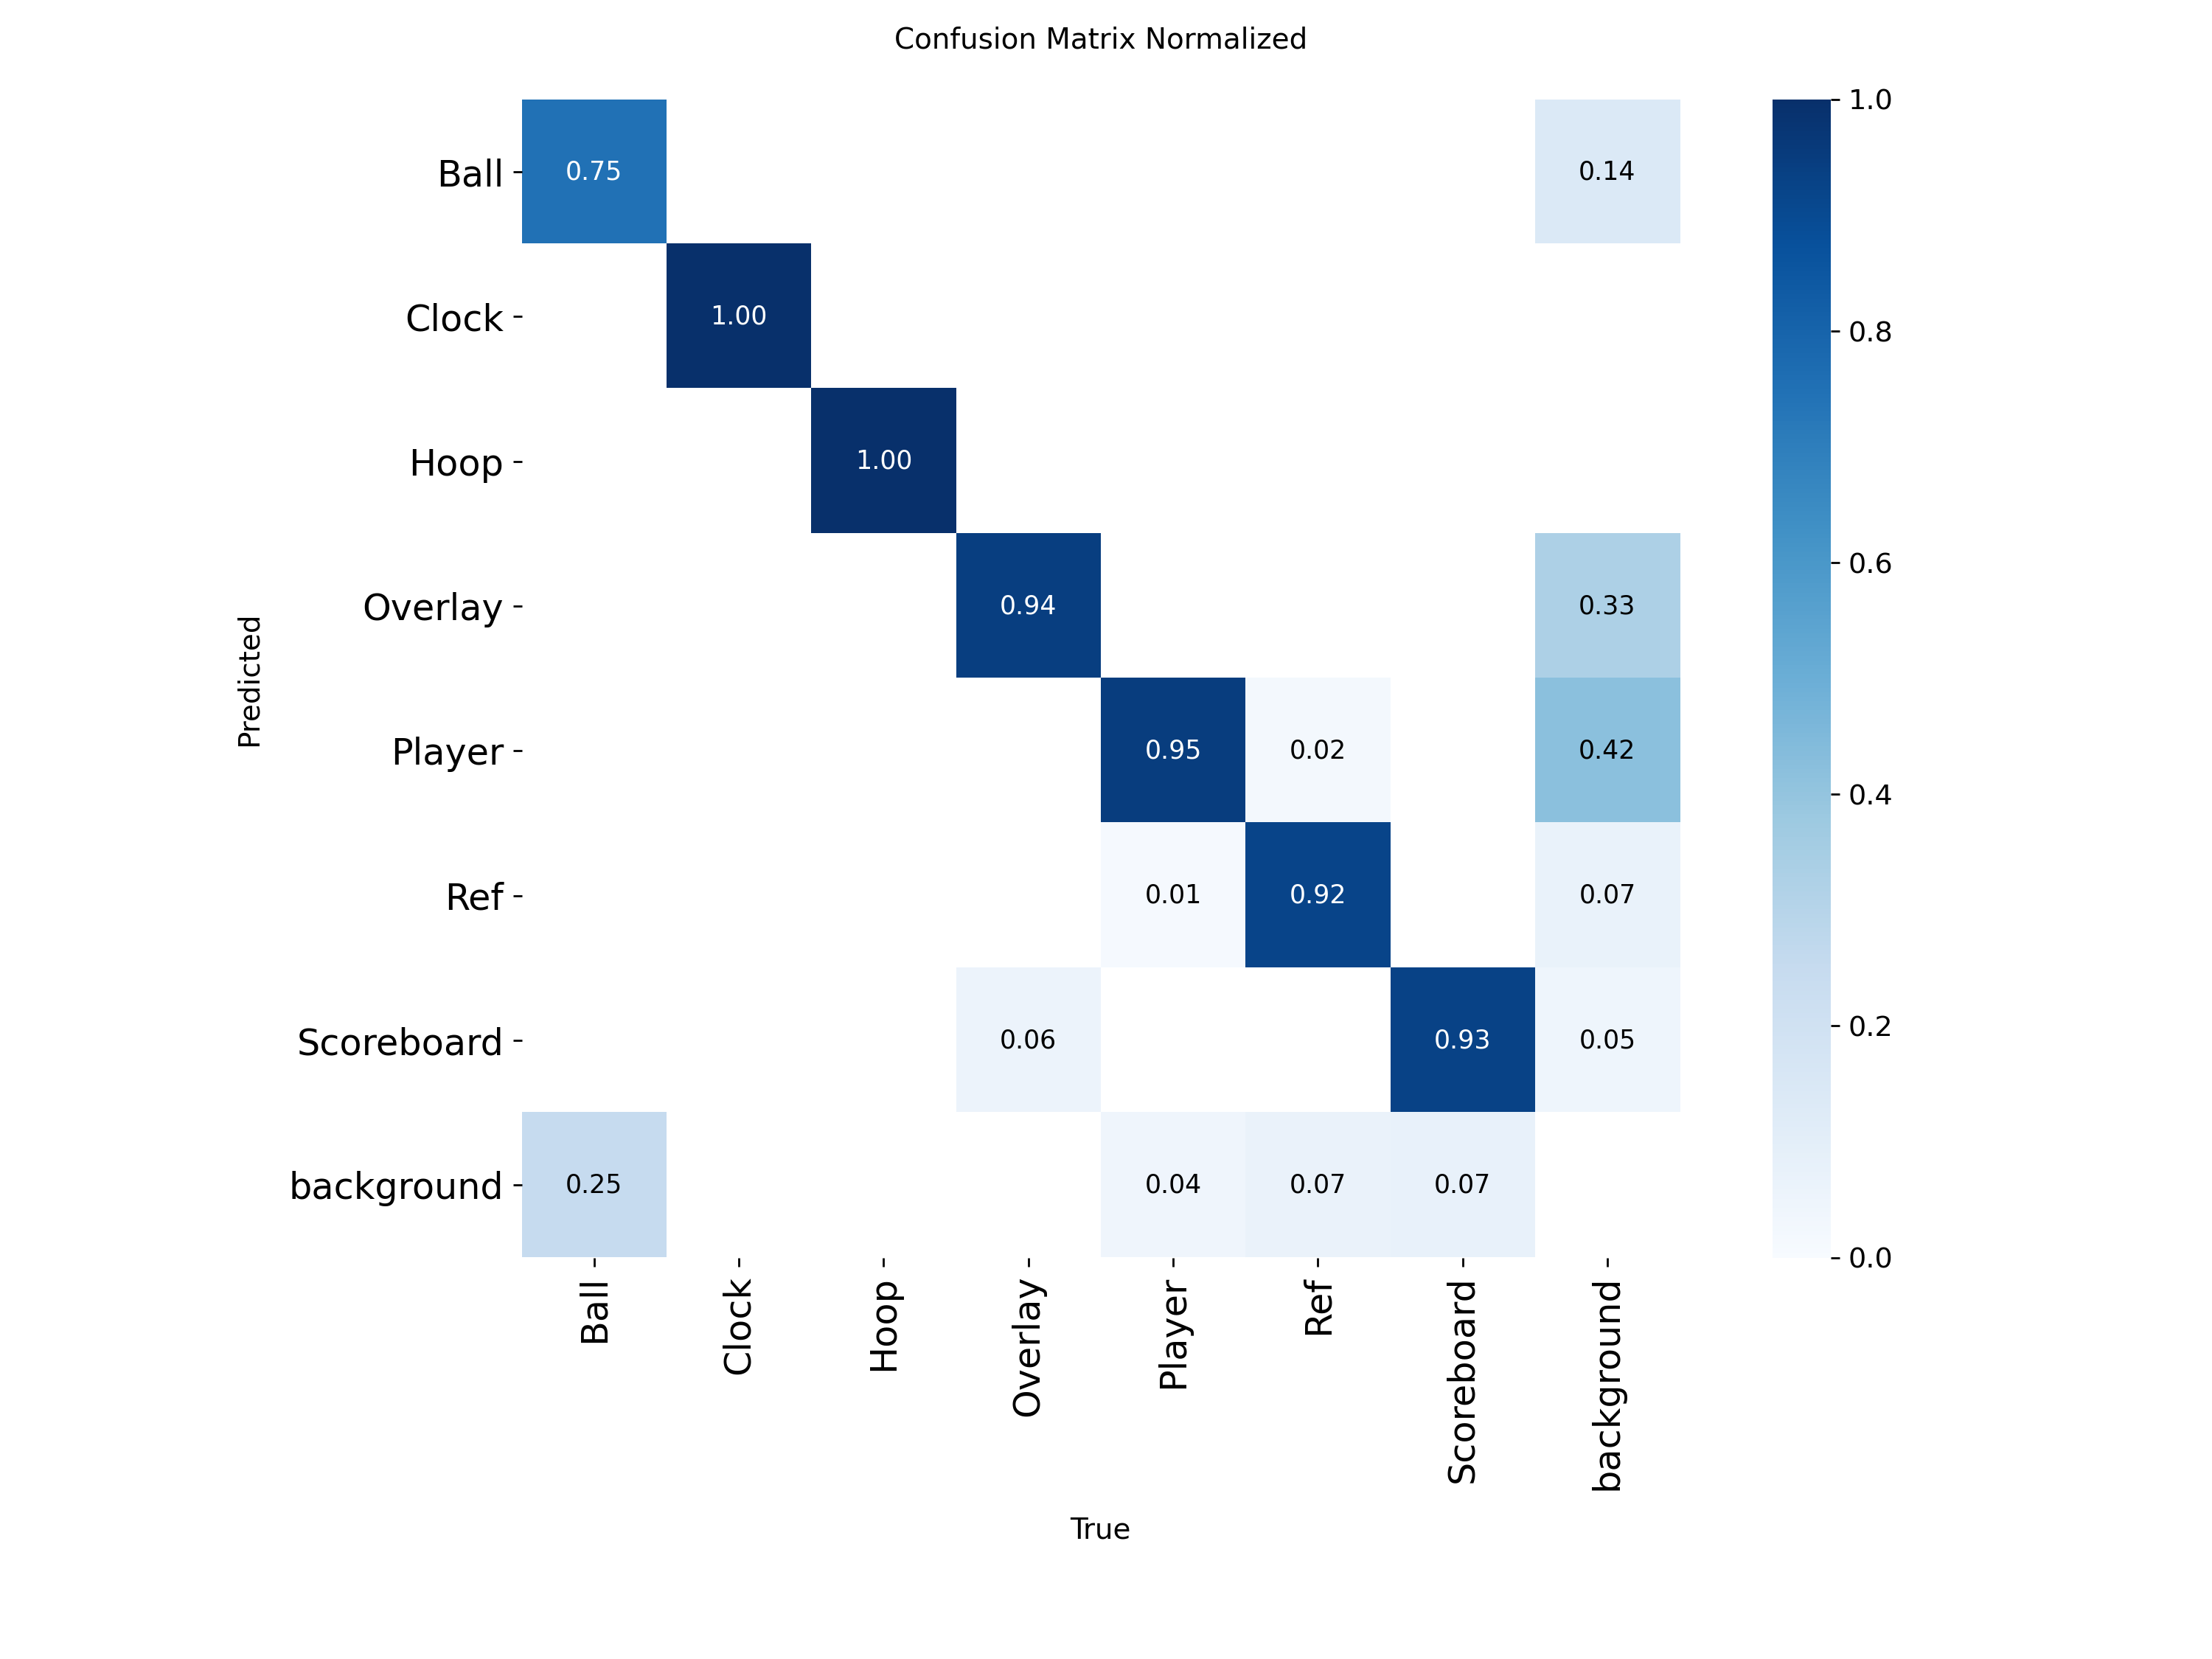

In [ ]:
from IPython.display import Image, display
import glob

for img_path in sorted(glob.glob("runs/detect/val4/*.png")):
    print(img_path)
    display(Image(filename=img_path))